[0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1]
[array([-0.9141497]), array([-1.05515979]), array([-1.11628601]), array([-1.13618945]), array([-1.13414767]), array([-1.12056013]), array([-1.10115032]), array([-1.07919294])]


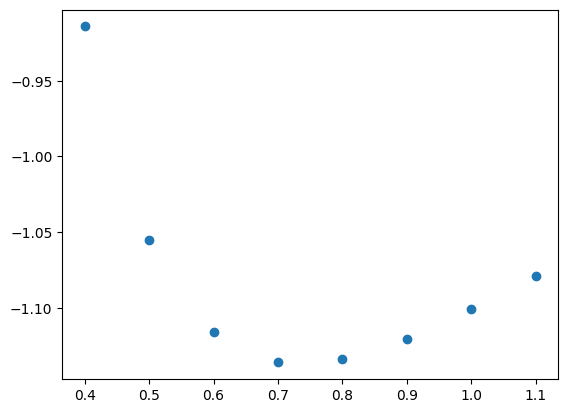

In [19]:
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver

distances = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1]
energies = []
for n in distances:
    driver = PySCFDriver(
        atom=f"H 0 0 0; H 0 0 {n}",
        basis="sto3g",
        charge=0,
        spin=0,
        unit=DistanceUnit.ANGSTROM,
    )
    es_problem = driver.run()
    
    from qiskit_nature.second_q.mappers import JordanWignerMapper
    mapper = JordanWignerMapper()
    
    from qiskit_algorithms import NumPyMinimumEigensolver
    numpy_solver = NumPyMinimumEigensolver()
    
    from qiskit_algorithms import VQE
    from qiskit_algorithms.optimizers import SLSQP
    from qiskit.primitives import Estimator
    from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
    
    ansatz = UCCSD(
        es_problem.num_spatial_orbitals,
        es_problem.num_particles,
        mapper,
        initial_state=HartreeFock(
            es_problem.num_spatial_orbitals,
            es_problem.num_particles,
            mapper,
        ),
    )
    
    vqe_solver = VQE(Estimator(), ansatz, SLSQP())
    vqe_solver.initial_point = [0.0] * ansatz.num_parameters
    
    from qiskit_nature.second_q.algorithms import GroundStateEigensolver
    calc = GroundStateEigensolver(mapper, vqe_solver)
    
    energy = calc.solve(es_problem)
    energies.append(energy.total_energies)




print(distances)
print(energies)
import matplotlib.pyplot as plt


plt.scatter(distances, energies)

